In [1]:
# ruff: noqa F401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import data_path, Set1

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import KernelPCA
from sklearn.manifold import trustworthiness

# Kernel PCA

[Kernel PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html#sklearn.decomposition.KernelPCA) and [Example](https://scikit-learn.org/stable/modules/decomposition.html#kernel-pca)

In [2]:
def smiles_to_bits(smiles):
    """Convert a SMILES string to bits."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol).astype(np.uint8)


def array_to_bitvect(x):
    """Convert a bit array to RDKit format."""
    # x is a 1D array of 0/1 values
    bitstring = "".join(x.astype(str))
    return DataStructs.CreateFromBitString(bitstring)


def tversky_kernel(x, y, alpha=0.7, beta=0.3):
    """Compute Tversky similarity for two fingerprints.

    For two sets A and B:
    T(A, B) = |A ∩ B| / (|A ∩ B| + α|A \\ B| + β|B \\ A|)
    where:

    |A ∩ B| = true positives (TP)
    |A \\ B| = in A but not B = false positives (FP) from B's perspective
    |B \\ A| = in B but not A = false negatives (FN) from B's perspective
    α, β ≥ 0 are weights you choose

    Setting α ≠ β lets you penalize FP and FN differently.
    For instance, you might set α < β (e.g. 0.3/0.7) to penalize false
    negatives more heavily than false positives

    """

    fp_x = array_to_bitvect(x)
    fp_y = array_to_bitvect(y)
    return DataStructs.TverskySimilarity(fp_x, fp_y, alpha, beta)

In [3]:
data = data_path("kernel_pca", "psychedelics_molecules.csv")
df = pd.read_csv(data, index_col=0)
display(df)

,Category,Canonical SMILES,Isomeric SMILES,IUPAC
Name,,,,
Quipazine,Piperazine,C1CN(CCN1)C2=NC3=CC=CC=C3C=C2,C1CN(CCN1)C2=NC3=CC=CC=C3C=C2,2-piperazin-1-ylquinoline
MK212,Piperazine,C1CN(CCN1)C2=CN=CC(=N2)Cl,C1CN(CCN1)C2=CN=CC(=N2)Cl,2-chloro-6-piperazin-1-ylpyrazine
"N,N-Dimethyltryptamine",Tryptamine,CN(C)CCC1=CNC2=CC=CC=C21,CN(C)CCC1=CNC2=CC=CC=C21,"2-(1H-indol-3-yl)-N,N-dimethylethanamine"
Psilocin,Tryptamine,CN(C)CCC1=CNC2=C1C(=CC=C2)O,CN(C)CCC1=CNC2=C1C(=CC=C2)O,3-[2-(dimethylamino)ethyl]-1H-indol-4-ol
Psilocybin,Tryptamine,CN(C)CCC1=CNC2=C1C(=CC=C2)OP(=O)(O)O,CN(C)CCC1=CNC2=C1C(=CC=C2)OP(=O)(O)O,[3-[2-(dimethylamino)ethyl]-1H-indol-4-yl] dih...
...,...,...,...,...
4-Fluoroamphetamine,Phenethylamine,CC(CC1=CC=C(C=C1)F)N,CC(CC1=CC=C(C=C1)F)N,1-(4-fluorophenyl)propan-2-amine
Norfenfluramine,Phenethylamine,CC(CC1=CC(=CC=C1)C(F)(F)F)N,CC(CC1=CC(=CC=C1)C(F)(F)F)N,1-[3-(trifluoromethyl)phenyl]propan-2-amine
Para-Iodoamphetamine,Phenethylamine,CC(CC1=CC=C(C=C1)I)N,CC(CC1=CC=C(C=C1)I)N,1-(4-iodophenyl)propan-2-amine


In [4]:
# -------------------------
# 1) SMILES -> bit vectors
# -------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,  # ECFP4
    fpSize=1024,
)

# df["smiles"] should contain SMILES strings
fps = df["Canonical SMILES"].apply(smiles_to_bits)
mask = fps.notna()

X = np.vstack(fps[mask].to_list())  # shape: (n_samples, n_bits)
df_valid = df.loc[mask].reset_index(drop=True)

In [5]:
# -----------------------------
# 4) Kernel PCA
# -----------------------------
kpca = KernelPCA(
    n_components=10,  # choose however many you want
    kernel=lambda a, b: tversky_kernel(a, b, alpha=0.7, beta=0.3),
    eigen_solver="auto",
)

Z = kpca.fit_transform(X)

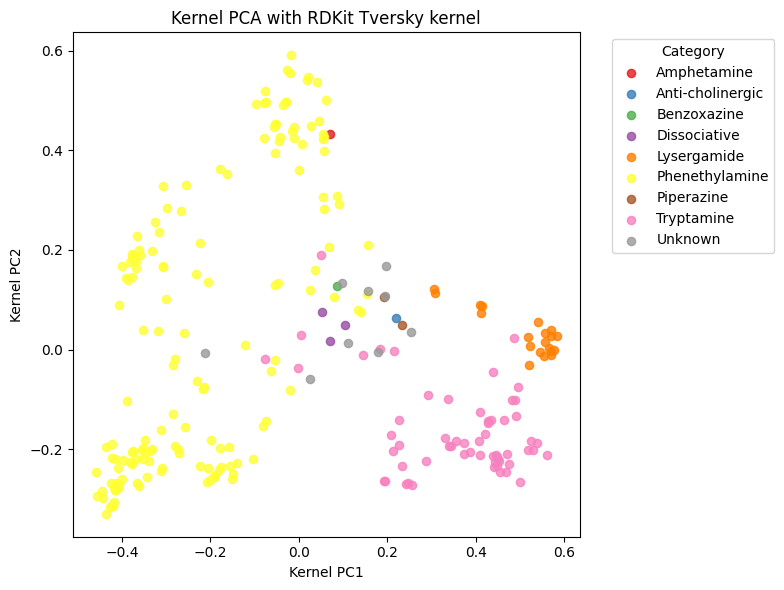

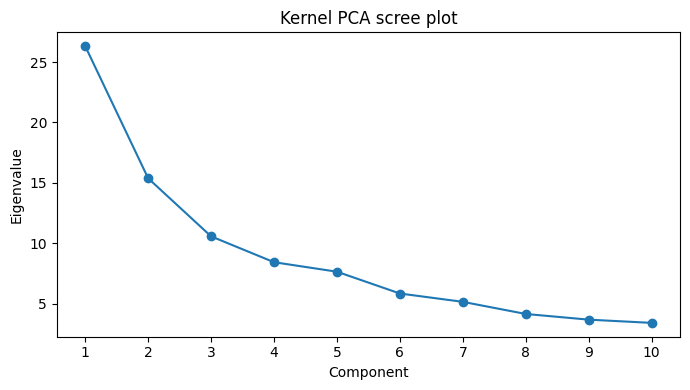

In [6]:
# -----------------------------
# 5) Scatter plot of first two components
# -----------------------------
plt.figure(figsize=(8, 6))

categories = df_valid["Category"].str.strip().astype(str)
unique_cats = sorted(categories.unique())
colors = Set1[min(len(unique_cats), 9)]

for i, cat in enumerate(unique_cats):
    idx = categories == cat
    plt.scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=35,
        alpha=0.8,
        label=cat,
        c=colors[i % len(colors)],
    )

plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.title("Kernel PCA with RDKit Tversky kernel")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Scree plot
# -----------------------------
eigvals = kpca.eigenvalues_

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(eigvals) + 1), eigvals, marker="o")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Kernel PCA scree plot")
plt.xticks(range(1, len(eigvals) + 1))
plt.tight_layout()
plt.show()

In [7]:
trustworthiness_score = trustworthiness(X, Z, n_neighbors=5)
print(f"Trustworthiness (k=5): {trustworthiness_score:.4f}")

Trustworthiness (k=5): 0.9189


# Radial Basis Function (RBF) kernel for comparison


In [8]:
kpca_rbf = KernelPCA(
    n_components=10,  # choose however many you want
    kernel="rbf",
    eigen_solver="auto",
)

Z_rbf = kpca_rbf.fit_transform(X)

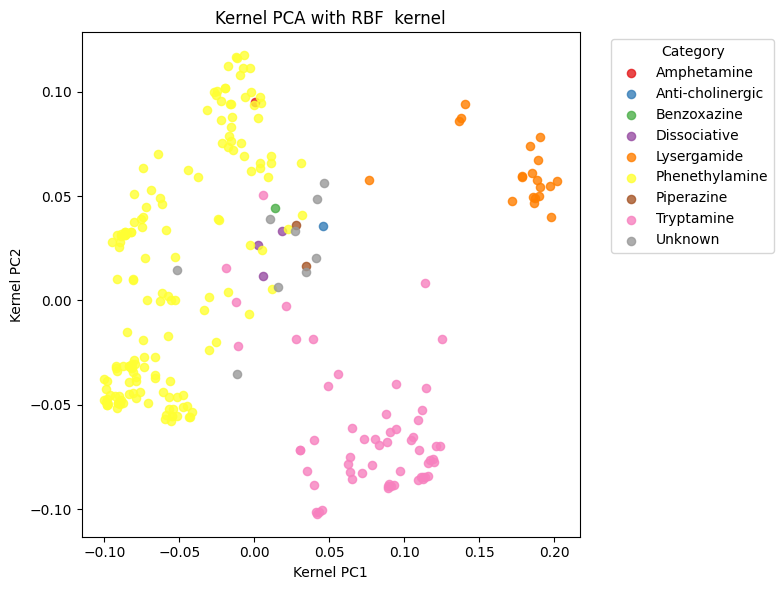

In [9]:
# -----------------------------
# 5) Scatter plot of first two components
# -----------------------------
plt.figure(figsize=(8, 6))

categories = df_valid["Category"].str.strip().astype(str)
unique_cats = sorted(categories.unique())
colors = Set1[min(len(unique_cats), 9)]

for i, cat in enumerate(unique_cats):
    idx = categories == cat
    plt.scatter(
        Z_rbf[idx, 0],
        Z_rbf[idx, 1],
        s=35,
        alpha=0.8,
        label=cat,
        c=colors[i % len(colors)],
    )

plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.title("Kernel PCA with RBF  kernel")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
trustworthiness_score = trustworthiness(X, Z_rbf, n_neighbors=5)
print(f"Trustworthiness (k=5): {trustworthiness_score:.4f}")

Trustworthiness (k=5): 0.9443
